# 03 — Autoencoder Anomaly Detector

Trains a tabular autoencoder on **BENIGN traffic only**. At inference time the
reconstruction MSE is compared to a threshold (chosen from the validation
benign percentile) — anything above is flagged anomalous, possibly a zero-day
attack the MLP has never seen.

## Purpose of the Autoencoder in this project

The Autoencoder is **not** a classifier and is **not** competing with the
MLP. Its three concrete roles:

1. **Zero-day / unknown-anomaly detection.** Trained on `BENIGN` only, it
   reconstructs typical traffic with low error and produces high MSE on
   anything off-manifold — including classes the MLP was never trained on
   (e.g. `Infiltration`, `Heartbleed`, future novel attacks).
2. **Defense in depth.** Used as a gate in the hybrid pipeline: if the MLP
   confidently says BENIGN but the AE disagrees, the production
   `SmartTIDS_Predictor` marks the flow as `UNKNOWN_ANOMALY`.
3. **Compressed representation.** The 6-D latent space is a learned
   non-linear embedding of normal traffic, useful for downstream
   visualisation and feature extraction.

It is **not used here for denoising** — the dataset is already cleaned in
NB 01 and we want the AE to faithfully reproduce inputs, not de-noise them.

---

## Table of Contents

1. [Load benign-only training and full validation set](#1.-Load-benign-only-training-and-full-validation-set)
2. [Autoencoder architecture (visual + summary)](#2.-Autoencoder-architecture)
3. [Train the baseline autoencoder](#3.-Train-the-baseline-autoencoder)
4. [Plot training & validation loss curves](#4.-Plot-training-&-validation-loss-curves)
5. [Reconstruction quality — global MSE/MAE on validation set](#5.-Reconstruction-quality)
6. [Per-feature reconstruction error](#6.-Per-feature-reconstruction-error)
7. [Visual original vs reconstructed comparison](#7.-Visual-original-vs-reconstructed-comparison)
8. [Hyperparameter tuning (latent dim, encoder depth, learning rate)](#8.-Hyperparameter-tuning)
9. [Retrain with best hyperparameters](#9.-Retrain-with-best-hyperparameters)
10. [Choose a threshold from BENIGN validation reconstruction error](#10.-Choose-a-threshold)
11. [BENIGN vs ATTACK error histograms](#11.-BENIGN-vs-ATTACK-error-histograms)
12. [Quality metrics — AUC, separation, per-class detection rate](#12.-Quality-metrics)
13. [Threshold sweep](#13.-Threshold-sweep)
14. [Persist autoencoder and threshold](#14.-Persist-autoencoder-and-threshold)

---


In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score

from src import config as cfg
sns.set_theme(style="whitegrid")


## 1. Load benign-only training and full validation set

In [2]:
train = pd.read_csv(cfg.PROCESSED_DIR / "train.csv")
val   = pd.read_csv(cfg.PROCESSED_DIR / "val.csv")

scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)

train_benign = train[train[cfg.LABEL_COL] == "BENIGN"]
print("Benign train rows:", len(train_benign))

X_train = scaler.transform(train_benign[feature_names].astype(np.float32).values)
X_val   = scaler.transform(val[feature_names].astype(np.float32).values)
y_val_is_attack = (val[cfg.LABEL_COL] != "BENIGN").astype(int).values

# --- Clip benign training outliers ---------------------------------------
# After StandardScaler, CICIDS still has heavy tails: a tiny fraction of
# benign rows have |z|>>5 on some features. They drag MSE up and keep the
# AE from learning the bulk of typical benign. Clipping z to +/-clip_z
# *only at training time* gives the AE a clean signal. At inference we
# do NOT clip — extreme values then become genuine anomaly signals.
clip_z = cfg.AE_CONFIG.get("outlier_clip_z", 5.0)
n_outliers = int((np.abs(X_train) > clip_z).any(axis=1).sum())
X_train = np.clip(X_train, -clip_z, clip_z).astype(np.float32)
print(f"Clipped to |z| <= {clip_z}: {n_outliers:,} rows touched "
      f"({n_outliers / len(X_train) * 100:.2f}%)")


Benign train rows: 1589924
Clipped to |z| <= 5.0: 146,043 rows touched (9.19%)


## 2. Autoencoder architecture (visual + summary)

A symmetric `Encoder -> Latent -> Decoder` network with **77 → 128 → 64 → 32 → 6 → 32 → 64 → 128 → 77**
neurons. Each Dense is followed by BatchNorm + LeakyReLU; the latent layer
uses linear activation so the bottleneck can represent positive *and*
negative deviations symmetrically.

```
Input (77)
   |
   v
[Dense 128] --> BN --> LeakyReLU      \
[Dense  64] --> BN --> LeakyReLU       |--- Encoder
[Dense  32] --> BN --> LeakyReLU      /
   |
[Dense   6] (linear)                  <--- Latent bottleneck
   |
[Dense  32] --> BN --> LeakyReLU      \
[Dense  64] --> BN --> LeakyReLU       |--- Decoder
[Dense 128] --> BN --> LeakyReLU      /
   |
[Dense  77] (linear)                  <--- Reconstruction
```

Loss = **MSE** on the standardised inputs; secondary metric = **MAE**.


In [3]:
def build_autoencoder(input_dim, encoder_units=(128, 64, 32),
                      latent_dim=6, learning_rate=5e-4):
    """Symmetric tabular autoencoder.

    Each Dense layer is followed by BatchNorm + LeakyReLU; the latent layer
    uses linear activation so the bottleneck can represent positive and
    negative deviations symmetrically.
    """
    inputs = layers.Input(shape=(input_dim,), name="features")
    x = inputs
    for i, units in enumerate(encoder_units):
        x = layers.Dense(units, name=f"enc_dense_{i}")(x)
        x = layers.BatchNormalization(name=f"enc_bn_{i}")(x)
        x = layers.LeakyReLU(negative_slope=0.1, name=f"enc_act_{i}")(x)
    latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)

    x = latent
    for i, units in enumerate(reversed(encoder_units)):
        x = layers.Dense(units, name=f"dec_dense_{i}")(x)
        x = layers.BatchNormalization(name=f"dec_bn_{i}")(x)
        x = layers.LeakyReLU(negative_slope=0.1, name=f"dec_act_{i}")(x)
    outputs = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)

    m = models.Model(inputs, outputs, name="smarttids_autoencoder")
    m.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
              loss="mse", metrics=["mae"])
    return m


ae = build_autoencoder(
    input_dim=X_train.shape[1],
    encoder_units=cfg.AE_CONFIG["encoder_units"],
    latent_dim=cfg.AE_CONFIG["latent_dim"],
    learning_rate=cfg.AE_CONFIG["learning_rate"],
)
ae.summary()


2026-05-18 06:39:14,389 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "smarttids_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_0 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_1 (LeakyReLU)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_2 (LeakyReLU)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_0 (LeakyReLU)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_1 (LeakyReLU)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_2 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 77)             │         9,933 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,899 (167.57 KB)

 Trainable params: 42,003 (164.07 KB)

 Non-trainable params: 896 (3.50 KB)

## 3. Train the baseline autoencoder

Train with the default `cfg.AE_CONFIG`. This is the baseline run; we'll
hyperparameter-tune in section 8 and retrain in section 9.


In [4]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=cfg.AE_CONFIG["patience"],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

# Train AE on benign only — internal val_split keeps things honest.
history = ae.fit(
    X_train, X_train,
    epochs=cfg.AE_CONFIG["epochs"],
    batch_size=cfg.AE_CONFIG["batch_size"],
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50
2795/2795 - 25s - 9ms/step - loss: 0.0359 - mae: 0.0796 - val_loss: 0.0108 - val_mae: 0.0441 - learning_rate: 5.0000e-04
Epoch 2/50
2795/2795 - 20s - 7ms/step - loss: 0.0114 - mae: 0.0487 - val_loss: 0.0079 - val_mae: 0.0368 - learning_rate: 5.0000e-04
Epoch 3/50
2795/2795 - 20s - 7ms/step - loss: 0.0090 - mae: 0.0433 - val_loss: 0.0074 - val_mae: 0.0378 - learning_rate: 5.0000e-04
Epoch 4/50
2795/2795 - 20s - 7ms/step - loss: 0.0079 - mae: 0.0404 - val_loss: 0.0059 - val_mae: 0.0314 - learning_rate: 5.0000e-04
Epoch 5/50
2795/2795 - 20s - 7ms/step - loss: 0.0071 - mae: 0.0384 - val_loss: 0.0057 - val_mae: 0.0310 - learning_rate: 5.0000e-04
Epoch 6/50
2795/2795 - 19s - 7ms/step - loss: 0.0066 - mae: 0.0370 - val_loss: 0.0050 - val_mae: 0.0284 - learning_rate: 5.0000e-04
Epoch 7/50
2795/2795 - 20s - 7ms/step - loss: 0.0062 - mae: 0.0359 - val_loss: 0.0049 - val_mae: 0.0280 - learning_rate: 5.0000e-04
Epoch 8/50
2795/2795 - 20s - 7ms/step - loss: 0.0059 - mae: 0.0349 - val_los

## 4. Training & validation loss curves

A healthy autoencoder shows:

* monotonically decreasing **training MSE**,
* **validation MSE** tracking training closely (small gap = no overfit),
* **MAE** decreasing in parallel.


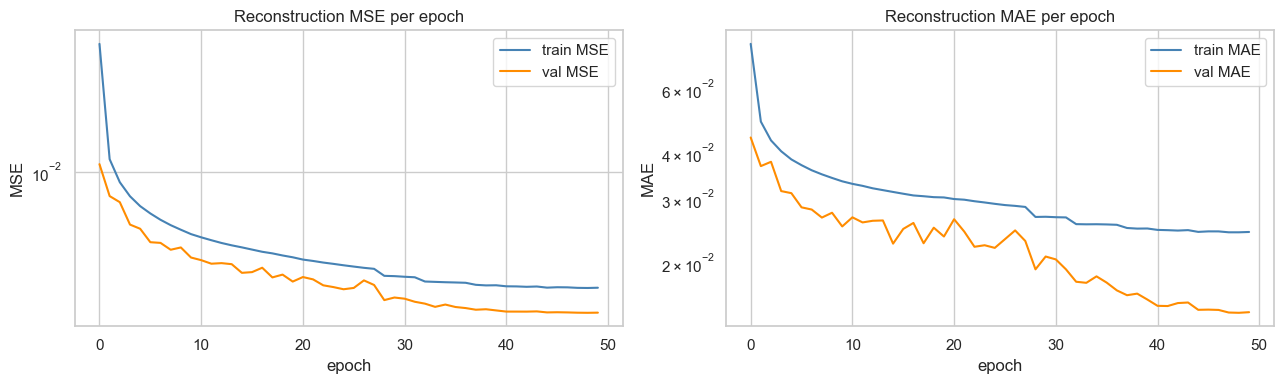

Final train MSE: 0.00316  |  val MSE: 0.00246
Final train MAE: 0.02429  |  val MAE: 0.01465


In [5]:
h = history.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h["loss"],     label="train MSE",      color="steelblue")
axes[0].plot(h["val_loss"], label="val MSE",        color="darkorange")
axes[0].set_title("Reconstruction MSE per epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_yscale("log"); axes[0].legend()

axes[1].plot(h["mae"],     label="train MAE",       color="steelblue")
axes[1].plot(h["val_mae"], label="val MAE",         color="darkorange")
axes[1].set_title("Reconstruction MAE per epoch")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("MAE")
axes[1].set_yscale("log"); axes[1].legend()

plt.tight_layout(); plt.show()

# Snapshot baseline history & val loss for NB 04 / before-after plots.
baseline_ae_history = {k: list(map(float, v)) for k, v in history.history.items()}
print(f"Final train MSE: {h['loss'][-1]:.5f}  |  val MSE: {h['val_loss'][-1]:.5f}")
print(f"Final train MAE: {h['mae'][-1]:.5f}  |  val MAE: {h['val_mae'][-1]:.5f}")


## 5. Reconstruction quality — global MSE/MAE on validation set

We measure reconstruction quality on the **full validation set** (BENIGN +
ATTACK) and report MSE / MAE / R² overall and split by class. A good benign
reconstruction (low MSE) and a clearly worse attack reconstruction (high
MSE) is exactly what makes the AE useful as an anomaly detector.


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict reconstructions for full val.
recon_val = ae.predict(X_val, batch_size=4096, verbose=0)
y_val_label = val[cfg.LABEL_COL].values

# Per-row error vectors -> aggregate to scalar metrics overall and per class.
mse_row = np.mean((X_val - recon_val) ** 2, axis=1)
mae_row = np.mean(np.abs(X_val - recon_val), axis=1)

quality_overall = {
    "mse":  float(mean_squared_error(X_val, recon_val)),
    "mae":  float(mean_absolute_error(X_val, recon_val)),
    "r2":   float(r2_score(X_val.flatten(), recon_val.flatten())),
}
print("Reconstruction quality on FULL validation set:")
for k, v in quality_overall.items():
    print(f"  {k.upper():<4}: {v:.5f}")

# Class-stratified table.
per_class_recon = []
for cls in np.unique(y_val_label):
    m = y_val_label == cls
    per_class_recon.append({
        "class":   cls,
        "support": int(m.sum()),
        "mse":     float(mse_row[m].mean()),
        "mae":     float(mae_row[m].mean()),
    })
recon_df = (pd.DataFrame(per_class_recon)
              .sort_values("mse"))
print("\nReconstruction error per class (sorted by MSE):")
print(recon_df.to_string(index=False))


Reconstruction quality on FULL validation set:
  MSE : 0.20774
  MAE : 0.06425
  R2  : 0.76063

Reconstruction error per class (sorted by MSE):
                   class  support      mse      mae
             FTP-Patator     1190 0.001205 0.019185
        Web Attack - XSS       98 0.002771 0.011432
             SSH-Patator      884 0.003701 0.028496
Web Attack - Brute Force      226 0.013983 0.023654
                PortScan    23820 0.017178 0.031883
                     Bot      294 0.130917 0.049873
                  BENIGN   340698 0.186493 0.031091
                    DDoS    19204 0.339194 0.223602
                DoS Hulk    34518 0.435957 0.304441
           DoS GoldenEye     1544 0.504548 0.265984
           DoS slowloris      870 0.679031 0.355066
        DoS Slowhttptest      825 1.483212 0.382814


## 6. Per-feature reconstruction error

Which feature dimensions does the autoencoder struggle to reconstruct? The
features with high per-column MSE on attack rows are the **most informative
dimensions for anomaly scoring** — they're where attacks visibly diverge
from normal traffic.


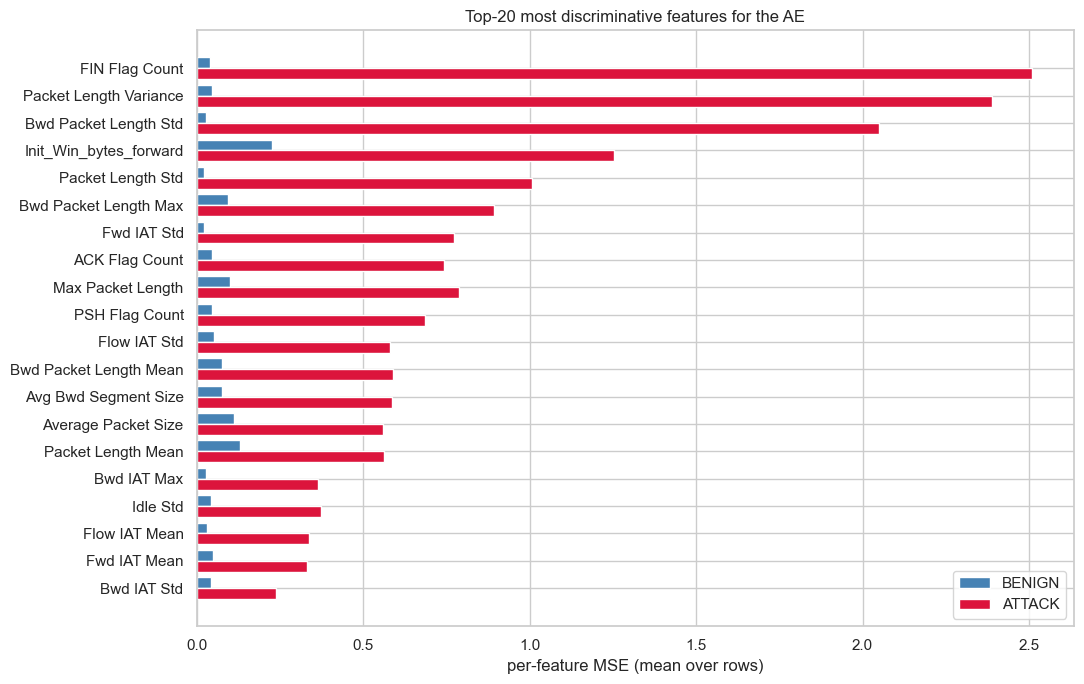

               feature  mse_benign  mse_attack  divergence
        FIN Flag Count    0.040785    2.509621    2.468836
Packet Length Variance    0.044466    2.389091    2.344625
 Bwd Packet Length Std    0.026740    2.049701    2.022961
Init_Win_bytes_forward    0.227111    1.253573    1.026462
     Packet Length Std    0.022499    1.007268    0.984769
 Bwd Packet Length Max    0.094245    0.893583    0.799337
           Fwd IAT Std    0.022415    0.771990    0.749575
        ACK Flag Count    0.046182    0.742615    0.696433
     Max Packet Length    0.098579    0.787559    0.688979
        PSH Flag Count    0.045953    0.685517    0.639564
          Flow IAT Std    0.051248    0.580892    0.529645
Bwd Packet Length Mean    0.074170    0.590277    0.516107
  Avg Bwd Segment Size    0.074676    0.587256    0.512581
   Average Packet Size    0.113019    0.559785    0.446766
    Packet Length Mean    0.129561    0.563476    0.433915
           Bwd IAT Max    0.026988    0.365533    0.3385

In [7]:
is_attack = (y_val_label != "BENIGN")
err_per_feature_benign = np.mean((X_val[~is_attack] - recon_val[~is_attack]) ** 2, axis=0)
err_per_feature_attack = np.mean((X_val[ is_attack] - recon_val[ is_attack]) ** 2, axis=0)

feat_err = (pd.DataFrame({
    "feature":     feature_names,
    "mse_benign":  err_per_feature_benign,
    "mse_attack":  err_per_feature_attack,
})
    .assign(divergence=lambda d: d["mse_attack"] - d["mse_benign"])
    .sort_values("divergence", ascending=False)
    .head(20))

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(feat_err))
ax.barh(y_pos - 0.2, feat_err["mse_benign"], height=0.4,
        label="BENIGN", color="steelblue")
ax.barh(y_pos + 0.2, feat_err["mse_attack"], height=0.4,
        label="ATTACK", color="crimson")
ax.set_yticks(y_pos); ax.set_yticklabels(feat_err["feature"])
ax.invert_yaxis()
ax.set_xlabel("per-feature MSE (mean over rows)")
ax.set_title("Top-20 most discriminative features for the AE")
ax.legend()
plt.tight_layout(); plt.show()
print(feat_err.to_string(index=False))


## 7. Visual original vs reconstructed comparison

The clearest, most intuitive sanity check for an autoencoder: pick a handful
of BENIGN and ATTACK rows, plot the input vector vs. its reconstruction.
For BENIGN, the two lines should overlap almost perfectly; for ATTACK, they
should noticeably diverge on some features — that divergence **is** the
anomaly signal.


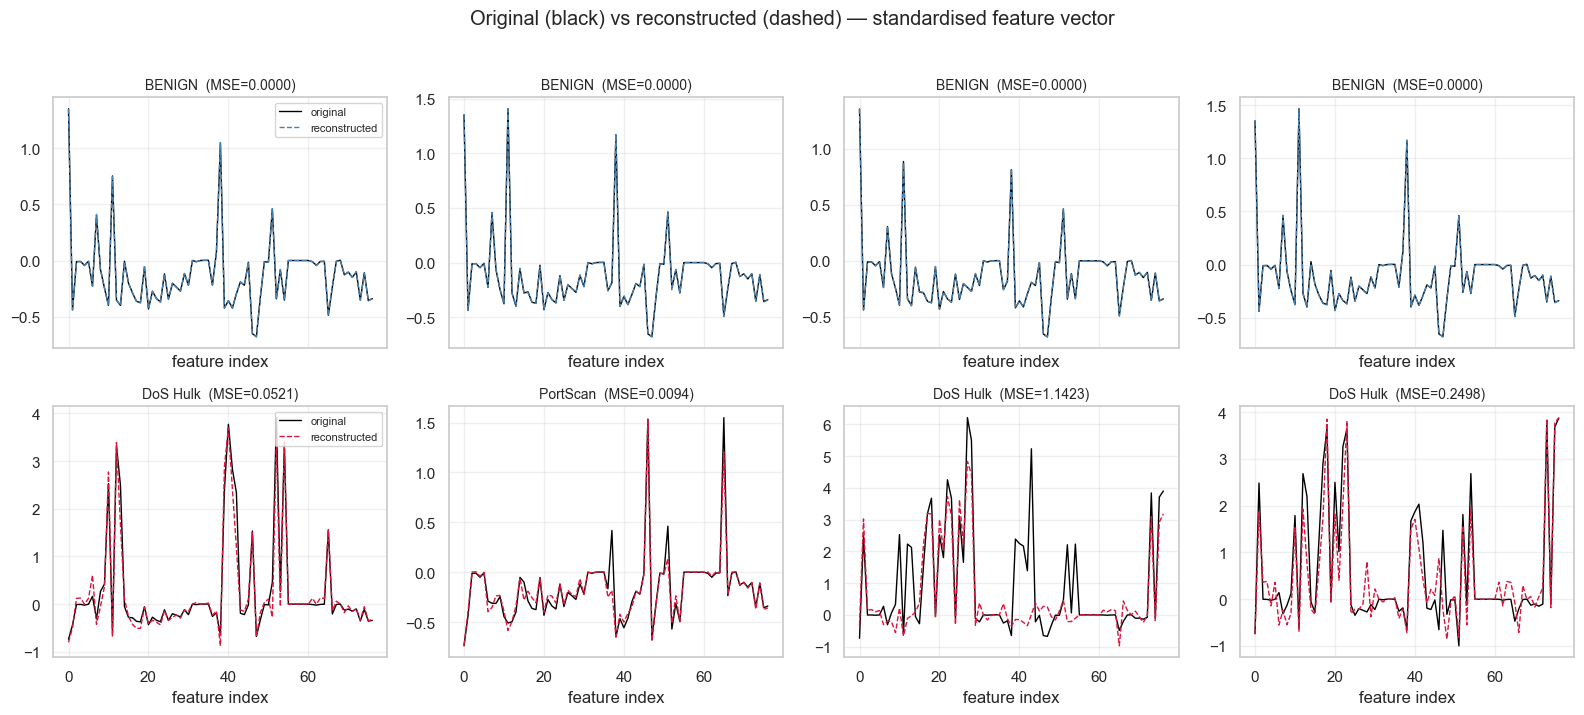

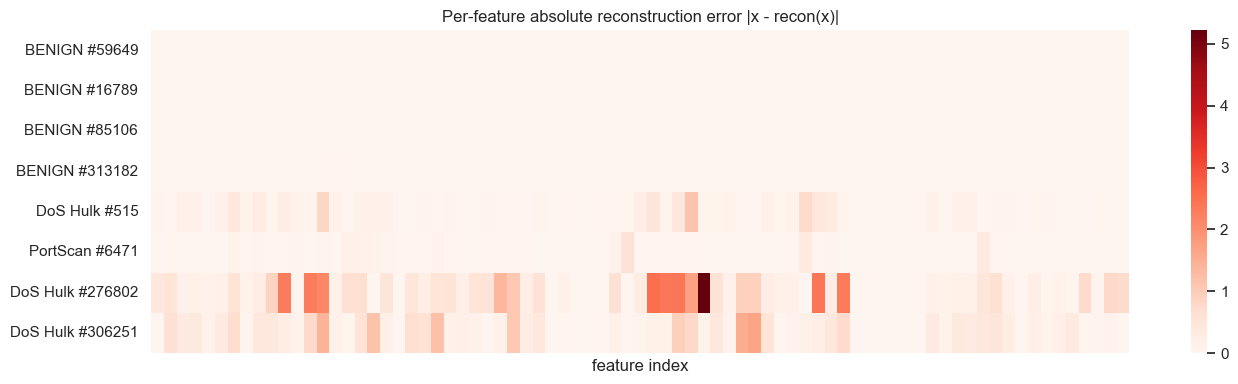

In [8]:
N_SAMPLES = 4
rng = np.random.RandomState(cfg.RANDOM_STATE)

benign_idx = rng.choice(np.where(~is_attack)[0], size=N_SAMPLES, replace=False)
attack_idx = rng.choice(np.where( is_attack)[0], size=N_SAMPLES, replace=False)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 7), sharex=True)

# Top row — BENIGN
for ax, i in zip(axes[0], benign_idx):
    ax.plot(X_val[i],     color="black",     lw=1.0, label="original")
    ax.plot(recon_val[i], color="steelblue", lw=1.0, ls="--", label="reconstructed")
    ax.set_title(f"BENIGN  (MSE={mse_row[i]:.4f})", fontsize=10)
    ax.set_xlabel("feature index")
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc="upper right", fontsize=8)

# Bottom row — ATTACK
for ax, i in zip(axes[1], attack_idx):
    ax.plot(X_val[i],     color="black",   lw=1.0, label="original")
    ax.plot(recon_val[i], color="crimson", lw=1.0, ls="--", label="reconstructed")
    ax.set_title(f"{y_val_label[i]}  (MSE={mse_row[i]:.4f})", fontsize=10)
    ax.set_xlabel("feature index")
    ax.grid(alpha=0.3)
axes[1, 0].legend(loc="upper right", fontsize=8)

plt.suptitle("Original (black) vs reconstructed (dashed) — standardised feature vector", y=1.02)
plt.tight_layout(); plt.show()

# Heatmap view: |X - recon| per (row, feature) for the chosen 8 examples.
chosen = np.concatenate([benign_idx, attack_idx])
diffs = np.abs(X_val[chosen] - recon_val[chosen])
labels = ([f"BENIGN #{i}" for i in benign_idx] +
          [f"{y_val_label[i]} #{i}" for i in attack_idx])

plt.figure(figsize=(14, 4))
sns.heatmap(diffs, cmap="Reds", xticklabels=False, yticklabels=labels, cbar=True)
plt.title("Per-feature absolute reconstruction error |x - recon(x)|")
plt.xlabel("feature index")
plt.tight_layout(); plt.show()


## 8. Hyperparameter tuning

Search over the autoencoder's structural and optimisation hyperparameters
on a stratified 200k-benign subsample:

| Hyperparameter   | Candidates                                  |
|------------------|---------------------------------------------|
| `encoder_units`  | `[64,32]`, `[128,64,32]`, `[256,128,64,32]` |
| `latent_dim`     | `4`, `6`, `8`, `12`                         |
| `learning_rate`  | `1e-3`, `5e-4`, `2e-4`                      |

For each config we run a short training (`TUNE_EPOCHS`) and score it by
**validation MSE on a held-out 20% benign slice**. Lowest val MSE wins.
Unlike the MLP search we don't do 3-fold CV here — the AE is unsupervised
and a single hold-out split is a faithful proxy for the production setup
(train on benign, threshold on benign val).


In [9]:
import itertools

ae_param_grid = {
    "encoder_units": [[64, 32], [128, 64, 32], [256, 128, 64, 32]],
    "latent_dim":    [4, 6, 8, 12],
    "learning_rate": [1e-3, 5e-4, 2e-4],
}
ae_all_configs = [dict(zip(ae_param_grid, vals))
                  for vals in itertools.product(*ae_param_grid.values())]

N_AE_TRIALS = 8
TUNE_EPOCHS = 15
TUNE_BATCH  = 1024
TUNE_SIZE   = 200_000

rng = np.random.RandomState(cfg.RANDOM_STATE)
rng.shuffle(ae_all_configs)
ae_configs_to_try = ae_all_configs[:N_AE_TRIALS]
print(f"AE configurations to evaluate: {len(ae_configs_to_try)} of {len(ae_all_configs)}")

# Subsample benign-only training set for tuning.
idx = rng.choice(len(X_train), size=min(TUNE_SIZE, len(X_train)), replace=False)
X_tune_ae = X_train[idx]
split = int(0.8 * len(X_tune_ae))
X_tr, X_va = X_tune_ae[:split], X_tune_ae[split:]
print(f"AE tuning split: train={len(X_tr):,}, val={len(X_va):,}")

ae_results = []
for i, params in enumerate(ae_configs_to_try, 1):
    print(f"\n[{i}/{len(ae_configs_to_try)}] {params}")
    m = build_autoencoder(
        input_dim=X_tr.shape[1],
        encoder_units=params["encoder_units"],
        latent_dim=params["latent_dim"],
        learning_rate=params["learning_rate"],
    )
    es = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    h = m.fit(X_tr, X_tr,
              validation_data=(X_va, X_va),
              epochs=TUNE_EPOCHS, batch_size=TUNE_BATCH,
              callbacks=[es], verbose=0)
    val_mse = float(np.min(h.history["val_loss"]))
    val_mae = float(np.min(h.history["val_mae"]))
    print(f"  val MSE: {val_mse:.5f}   val MAE: {val_mae:.5f}")
    ae_results.append({**params,
                       "val_mse": val_mse,
                       "val_mae": val_mae,
                       "n_params": int(m.count_params())})
    tf.keras.backend.clear_session()

ae_tuning_df = (pd.DataFrame(ae_results)
                  .sort_values("val_mse")
                  .reset_index(drop=True))
print("\n=== AE hyperparameter search results ===")
print(ae_tuning_df.to_string(index=False))

best_ae_params = ae_tuning_df.iloc[0][["encoder_units", "latent_dim",
                                        "learning_rate"]].to_dict()
print(f"\nBest AE params : {best_ae_params}")
print(f"Best val MSE   : {ae_tuning_df.iloc[0]['val_mse']:.5f}")

ae_tuning_df.to_csv(cfg.MODELS_DIR / "ae_tuning_results.csv", index=False)
with open(cfg.MODELS_DIR / "ae_best_params.json", "w") as f:
    json.dump({k: (list(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
               for k, v in best_ae_params.items()}, f, indent=2)
print(f"Saved tuning results -> {cfg.MODELS_DIR / 'ae_tuning_results.csv'}")


AE configurations to evaluate: 8 of 36
AE tuning split: train=160,000, val=40,000

[1/8] {'encoder_units': [256, 128, 64, 32], 'latent_dim': 12, 'learning_rate': 0.0002}
  val MSE: 0.00849   val MAE: 0.03845



2026-05-18 06:57:14,505 [WARNING] tensorflow: From d:\smart_ids\smart_ids\ids_pfa\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.




[2/8] {'encoder_units': [128, 64, 32], 'latent_dim': 4, 'learning_rate': 0.0005}
  val MSE: 0.01714   val MAE: 0.05056

[3/8] {'encoder_units': [256, 128, 64, 32], 'latent_dim': 4, 'learning_rate': 0.0002}
  val MSE: 0.01642   val MAE: 0.04898

[4/8] {'encoder_units': [256, 128, 64, 32], 'latent_dim': 8, 'learning_rate': 0.001}
  val MSE: 0.00623   val MAE: 0.03670

[5/8] {'encoder_units': [128, 64, 32], 'latent_dim': 6, 'learning_rate': 0.0005}
  val MSE: 0.01176   val MAE: 0.04501

[6/8] {'encoder_units': [256, 128, 64, 32], 'latent_dim': 8, 'learning_rate': 0.0005}
  val MSE: 0.00766   val MAE: 0.03734

[7/8] {'encoder_units': [128, 64, 32], 'latent_dim': 12, 'learning_rate': 0.001}
  val MSE: 0.00618   val MAE: 0.03519

[8/8] {'encoder_units': [128, 64, 32], 'latent_dim': 4, 'learning_rate': 0.001}
  val MSE: 0.01425   val MAE: 0.04782

=== AE hyperparameter search results ===
     encoder_units  latent_dim  learning_rate  val_mse  val_mae  n_params
     [128, 64, 32]          12 

## 9. Retrain with best hyperparameters

Retrain the autoencoder on the *full* benign training set with the winning
configuration, full epochs, and our normal callback suite. We then **rebind
`ae`** so the existing downstream cells (threshold, sweep, persist) just
work with the tuned model.


In [10]:
import gc

# Free memory accumulated by the baseline AE, the reconstruction-quality
# analysis (sections 5-7), and the hyperparameter search (section 8)
# before allocating the tuned model. Without this we hit a MemoryError
# when Keras tries to carve out the validation_split slice (~46 MB on
# top of an already saturated kernel).
_kill_list = [
    "ae", "recon_val", "mse_row", "mae_row",
    "err_per_feature_benign", "err_per_feature_attack", "feat_err",
    "diffs", "chosen", "plot_df",
    "X_tune_ae", "X_tr", "X_va", "m", "h",
    "ae_results", "ae_configs_to_try", "ae_all_configs",
]
for _name in _kill_list:
    if _name in globals():
        del globals()[_name]
tf.keras.backend.clear_session()
gc.collect()

# Build the tuned AE.
ae_tuned = build_autoencoder(
    input_dim=X_train.shape[1],
    encoder_units=best_ae_params["encoder_units"],
    latent_dim=int(best_ae_params["latent_dim"]),
    learning_rate=float(best_ae_params["learning_rate"]),
)
ae_tuned.summary()

# Pre-slice the validation split ourselves so Keras does not need to copy
# the full training array internally to satisfy validation_split=0.1.
# NumPy slicing returns a view - no extra allocation.
_split = int(0.9 * len(X_train))
X_tr_final = X_train[:_split]
X_va_final = X_train[_split:]

callbacks_tuned = [
    EarlyStopping(monitor="val_loss", patience=cfg.AE_CONFIG["patience"],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

history_tuned = ae_tuned.fit(
    X_tr_final, X_tr_final,
    validation_data=(X_va_final, X_va_final),
    epochs=cfg.AE_CONFIG["epochs"],
    batch_size=cfg.AE_CONFIG["batch_size"],
    callbacks=callbacks_tuned,
    verbose=2,
)

# Persist tuned history for NB 04 comparison plots.
tuned_ae_history = {k: list(map(float, v)) for k, v in history_tuned.history.items()}
with open(cfg.MODELS_DIR / "ae_tuned_history.json", "w") as f:
    json.dump({"baseline_history": baseline_ae_history,
               "tuned_history":    tuned_ae_history,
               "best_params":      {k: (list(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
                                    for k, v in best_ae_params.items()}},
              f, indent=2)
print(f"\nTuned AE history saved -> {cfg.MODELS_DIR / 'ae_tuned_history.json'}")

# Rebind ae and history so the existing downstream cells run on the tuned model.
ae      = ae_tuned
history = history_tuned

# Free the train/val views now that fit() is done.
del X_tr_final, X_va_final
gc.collect()

# Quick comparison: baseline vs tuned final val_loss
print(f"\nBaseline best val MSE: {min(baseline_ae_history['val_loss']):.5f}")
print(f"Tuned    best val MSE: {min(tuned_ae_history['val_loss']):.5f}")


Model: "smarttids_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_0 (Dense)             │ (None, 128)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_0 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_0 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_1 (LeakyReLU)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_act_2 (LeakyReLU)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_0 (Dense)             │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_0 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_0 (LeakyReLU)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_1 (LeakyReLU)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn_2 (BatchNormalization)   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_act_2 (LeakyReLU)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 77)             │         9,933 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,289 (169.10 KB)

 Trainable params: 42,393 (165.60 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
2795/2795 - 26s - 9ms/step - loss: 0.0221 - mae: 0.0645 - val_loss: 0.0068 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 2/50
2795/2795 - 21s - 8ms/step - loss: 0.0071 - mae: 0.0413 - val_loss: 0.0050 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 3/50
2795/2795 - 22s - 8ms/step - loss: 0.0054 - mae: 0.0362 - val_loss: 0.0038 - val_mae: 0.0277 - learning_rate: 0.0010
Epoch 4/50
2795/2795 - 21s - 8ms/step - loss: 0.0044 - mae: 0.0330 - val_loss: 0.0030 - val_mae: 0.0262 - learning_rate: 0.0010
Epoch 5/50
2795/2795 - 22s - 8ms/step - loss: 0.0039 - mae: 0.0308 - val_loss: 0.0023 - val_mae: 0.0221 - learning_rate: 0.0010
Epoch 6/50
2795/2795 - 21s - 7ms/step - loss: 0.0035 - mae: 0.0293 - val_loss: 0.0024 - val_mae: 0.0249 - learning_rate: 0.0010
Epoch 7/50
2795/2795 - 21s - 8ms/step - loss: 0.0032 - mae: 0.0281 - val_loss: 0.0022 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 8/50
2795/2795 - 21s - 7ms/step - loss: 0.0030 - mae: 0.0272 - val_loss: 0.0023 - val_mae: 0.0235 

## 10. Choose a threshold from BENIGN validation reconstruction error

In [11]:
def reconstruction_error(model, X):
    """Per-row MSE between input and reconstruction."""
    recon = model.predict(X, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)


val_benign = val[val[cfg.LABEL_COL] == "BENIGN"]
X_val_benign = scaler.transform(val_benign[feature_names].astype(np.float32).values)

err_benign_val = reconstruction_error(ae, X_val_benign)
threshold = float(np.percentile(err_benign_val, cfg.AE_CONFIG["threshold_percentile"]))
print(f"Threshold (P{cfg.AE_CONFIG['threshold_percentile']}):", threshold)


Threshold (P95.0): 0.010354907251894474


## 11. BENIGN vs ATTACK error histograms

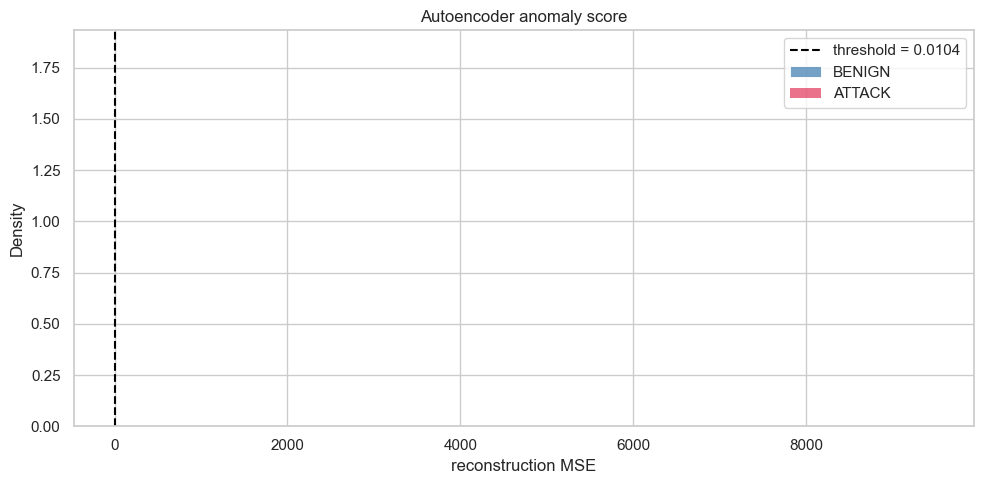

In [12]:
val_attack = val[val[cfg.LABEL_COL] != "BENIGN"]
X_val_attack = scaler.transform(val_attack[feature_names].astype(np.float32).values)
err_attack_val = reconstruction_error(ae, X_val_attack)

plt.figure(figsize=(10, 5))
sns.histplot(err_benign_val, bins=80, color="steelblue", label="BENIGN", stat="density")
sns.histplot(err_attack_val, bins=80, color="crimson",  label="ATTACK", stat="density",
             alpha=0.6)
plt.axvline(threshold, color="black", ls="--", label=f"threshold = {threshold:.4f}")
plt.xlabel("reconstruction MSE"); plt.title("Autoencoder anomaly score")
plt.legend(); plt.tight_layout(); plt.show()


## 12. Quality metrics — AUC, separation, per-class detection rate

Histogram tells the visual story. These numbers tell us *quantitatively*
how usable the AE is as an anomaly detector.


In [13]:
def autoencoder_anomaly_metrics(err, y_is_attack, threshold):
    """Binary metrics for the AE used as 'is this an attack at all?'."""
    y_pred = (err > threshold).astype(int)
    tp = int(((y_pred == 1) & (y_is_attack == 1)).sum())
    fp = int(((y_pred == 1) & (y_is_attack == 0)).sum())
    fn = int(((y_pred == 0) & (y_is_attack == 1)).sum())
    tn = int(((y_pred == 0) & (y_is_attack == 0)).sum())
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-9)
    try:
        auc = roc_auc_score(y_is_attack, err)
    except ValueError:
        auc = float("nan")
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1, "auc": auc}


# Reconstruction error on full validation set (already computed pieces above).
err_all = np.concatenate([err_benign_val, err_attack_val])
y_all   = np.concatenate([np.zeros(len(err_benign_val)),
                          np.ones (len(err_attack_val))])

print("=" * 60)
print("OVERALL AE QUALITY")
print("=" * 60)
auc = roc_auc_score(y_all, err_all)
print(f"ROC-AUC                 : {auc:.4f}    (1.0 = perfect, 0.5 = random)")

stats = autoencoder_anomaly_metrics(err_all, y_all.astype(int), threshold)
for k, v in stats.items():
    line = f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}"
    print(line)

# Separation: median attack error vs threshold
sep = np.median(err_attack_val) / max(threshold, 1e-9)
print(f"\nSeparation (median_attack / threshold): {sep:.2f}x")
print("  > 2x = clean separation, ~1x = AE only marginally useful")


OVERALL AE QUALITY
ROC-AUC                 : 0.8453    (1.0 = perfect, 0.5 = random)
  tp        : 36690
  fp        : 17035
  fn        : 46783
  tn        : 323663
  precision : 0.6829
  recall    : 0.4395
  f1        : 0.5348
  auc       : 0.8453

Separation (median_attack / threshold): 0.37x
  > 2x = clean separation, ~1x = AE only marginally useful


### Per-attack-class detection rate

Tells us *which* attacks the AE catches at the current threshold and which
slip through. A detector with 95% recall on DDoS but 5% on web attacks is
still useful, but you need to know that.


                   class  support  detection_rate  median_err
        DoS Slowhttptest      825        0.956364    0.183439
                DoS Hulk    34518        0.655484    0.350366
           DoS GoldenEye     1544        0.649611    0.023557
           DoS slowloris      870        0.591954    0.269073
                    DDoS    19204        0.591752    0.025718
Web Attack - Brute Force      226        0.044248    0.000058
                     Bot      294        0.037415    0.000264
                PortScan    23820        0.014945    0.001292
        Web Attack - XSS       98        0.010204    0.000055
             FTP-Patator     1190        0.009244    0.001368
             SSH-Patator      884        0.004525    0.003297


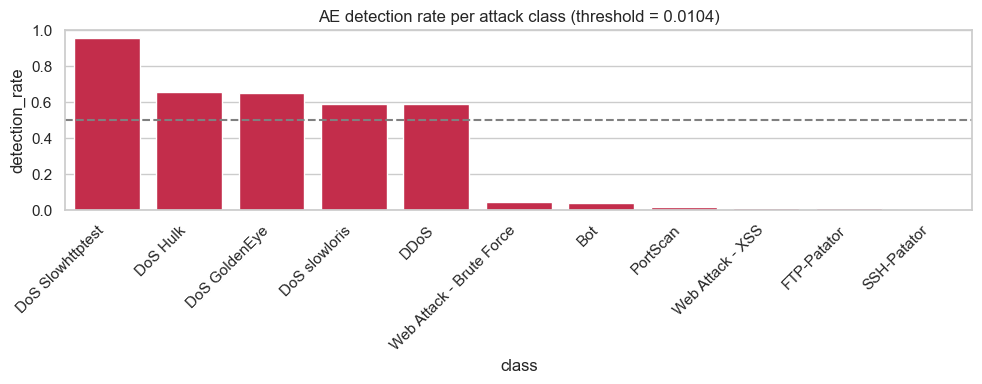

In [14]:
val_attack_labels = val.loc[val[cfg.LABEL_COL] != "BENIGN", cfg.LABEL_COL].values

per_class = []
for cls in np.unique(val_attack_labels):
    mask = val_attack_labels == cls
    errs = err_attack_val[mask]
    detected = (errs > threshold).sum()
    per_class.append({
        "class":         cls,
        "support":       int(mask.sum()),
        "detection_rate": detected / max(mask.sum(), 1),
        "median_err":    float(np.median(errs)),
    })

per_class_df = (pd.DataFrame(per_class)
                  .sort_values("detection_rate", ascending=False))
print(per_class_df.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=per_class_df, x="class", y="detection_rate", color="crimson")
plt.axhline(0.5, ls="--", color="gray")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title(f"AE detection rate per attack class (threshold = {threshold:.4f})")
plt.tight_layout(); plt.show()


## 13. Threshold sweep

The "right" threshold trades false positives against missed attacks. The
sweep below shows how F1, precision, and recall behave at different benign
percentiles. We pick whichever percentile gives the highest F1.


In [15]:
percentiles = [90, 95, 97, 99, 99.5, 99.9]
sweep = []
for p in percentiles:
    thr = float(np.percentile(err_benign_val, p))
    s = autoencoder_anomaly_metrics(err_all, y_all.astype(int), thr)
    sweep.append({"percentile": p, "threshold": thr,
                  "precision": s["precision"], "recall": s["recall"],
                  "f1": s["f1"], "false_positive_rate": s["fp"] / max(s["fp"]+s["tn"], 1)})
sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))

best = sweep_df.loc[sweep_df["f1"].idxmax()]
print(f"\nBest F1 at percentile P{best['percentile']}: "
      f"threshold={best['threshold']:.4f} (F1={best['f1']:.4f})")

# Use the best percentile from the sweep, not the config default.
threshold = float(best["threshold"])
print(f"\nUsing threshold = {threshold:.4f} for the saved model.")


 percentile  threshold  precision   recall       f1  false_positive_rate
       90.0   0.002193   0.573100 0.547938 0.560237             0.100001
       95.0   0.010355   0.682922 0.439543 0.534847             0.050000
       97.0   0.041561   0.758757 0.385119 0.510915             0.030000
       99.0   0.465781   0.799210 0.162460 0.270029             0.010000
       99.5   0.933545   0.525084 0.022570 0.043280             0.005001
       99.9   3.847091   0.107612 0.000491 0.000978             0.000998

Best F1 at percentile P90.0: threshold=0.0022 (F1=0.5602)

Using threshold = 0.0022 for the saved model.


## 14. Persist autoencoder and threshold

In [16]:
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
ae.save(cfg.AE_MODEL_FILE)
with open(cfg.AE_THRESHOLD_FILE, "w") as f:
    json.dump({"threshold": threshold,
               "percentile": cfg.AE_CONFIG["threshold_percentile"]}, f, indent=2)

print("Saved AE   ->", cfg.AE_MODEL_FILE)
print("Saved thr  ->", cfg.AE_THRESHOLD_FILE)


Saved AE   -> D:\smart_ids\smart_ids\models\autoencoder_model.keras
Saved thr  -> D:\smart_ids\smart_ids\models\autoencoder_threshold.json


---
## Outputs of this notebook

| Artifact | Path |
|---|---|
| Tuned autoencoder              | `models/autoencoder_model.keras` |
| Anomaly threshold              | `models/autoencoder_threshold.json` |
| AE tuning results              | `models/ae_tuning_results.csv` |
| AE best params                 | `models/ae_best_params.json` |
| AE baseline + tuned history    | `models/ae_tuned_history.json` |

**Next:** `04_evaluation_and_comparison.ipynb` — final evaluation on the test
set, before/after tuning comparison, hybrid MLP+AE evaluation, and
conclusions.
